# Module 03: Spacecraft Dynamics — SpacecraftContainer, Effectors & State

This module goes deeper into the `spacecraft` module, explaining the full 6-DOF dynamics model and how to attach physical components via **state effectors** and **dynamic effectors**.

### Learning Objectives
- Understand the spacecraft hub state vector (translation + rotation)
- Distinguish `stateEffectors` from `dynamicEffectors`
- Add reaction wheels (RWs) as state effectors
- Add thruster dynamics as dynamic effectors
- Read hub and effector output messages

---

## 1. The Spacecraft Hub State Vector

The `spacecraft.Spacecraft` object integrates the **coupled translational + rotational** equations of motion. The state vector includes:

| State | Symbol | Description |
|---|---|---|
| `r_CN_N` | position | CoM position in inertial N-frame (m) |
| `v_CN_N` | velocity | CoM velocity in inertial N-frame (m/s) |
| `sigma_BN` | MRP attitude | Modified Rodrigues Parameters (body wrt inertial) |
| `omega_BN_B` | angular rate | Angular velocity of body in body frame (rad/s) |

### Modified Rodrigues Parameters (MRP)
MRPs are a non-singular attitude parameterization (within ±360°). Given MRP vector **σ**:
- **σ = 0** → identity (no rotation)
- Singularity at |**σ**| = 1 → use shadow set `σ_s = -σ/|σ|²`
- Basilisk automatically switches to the shadow set to avoid singularity

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
os.makedirs('plots', exist_ok=True)

from Basilisk.utilities import SimulationBaseClass, macros, orbitalMotion, unitTestSupport
from Basilisk.utilities import simIncludeGravBody, simIncludeRW
from Basilisk.simulation import spacecraft, reactionWheelStateEffector
from Basilisk.architecture import bskLogging

bskLogging.setDefaultLogLevel(bskLogging.BSK_WARNING)
print("Imports OK.")

Imports OK.


---

## 2. Full Hub Configuration with Rotational Dynamics

In [2]:
# ── Constants ─────────────────────────────────────────────────────────────────
mu_earth = 3.986004418e14
R_earth  = 6371e3

# ── Simulation skeleton ───────────────────────────────────────────────────────
scSim   = SimulationBaseClass.SimBaseClass()
dynProc = scSim.CreateNewProcess("DynamicsProcess")
dt      = macros.sec2nano(1.0)
dynTask = scSim.CreateNewTask("DynamicsTask", dt)
dynProc.addTask(dynTask)

# ── Spacecraft object ─────────────────────────────────────────────────────────
scObject = spacecraft.Spacecraft()
scObject.ModelTag = "cubesat_3U"

# Hub mass properties
scObject.hub.mHub = 4.0   # 4 kg — typical 3U CubeSat

# Inertia tensor (principal axes for a 3U: 10x10x30 cm)
# I_xx = I_yy ~ m*(a^2+b^2)/12, I_zz ~ m*(a^2+a^2)/12 (using symmetry)
Ixx = 4.0 * (0.10**2 + 0.10**2) / 12  # ~0.00667 kg*m^2
Iyy = 4.0 * (0.10**2 + 0.30**2) / 12  # ~0.03333 kg*m^2
Izz = 4.0 * (0.10**2 + 0.30**2) / 12

I3x3 = np.diag([Ixx, Iyy, Izz])
scObject.hub.IHubPntBc_B = unitTestSupport.np2EigenMatrix3d(I3x3.flatten())
scObject.hub.r_BcB_B     = [[0.0], [0.0], [0.0]]

# ── Initial conditions ────────────────────────────────────────────────────────
oe = orbitalMotion.ClassicElements()
oe.a     = R_earth + 400e3
oe.e     = 0.0
oe.i     = 51.6 * macros.D2R   # ISS-like inclination
oe.Omega = 0.0
oe.omega = 0.0
oe.f     = 0.0

r0, v0 = orbitalMotion.elem2rv(mu_earth, oe)
scObject.hub.r_CN_NInit = r0.tolist()
scObject.hub.v_CN_NInit = v0.tolist()

# Initial attitude: body aligned with inertial (sigma = 0)
scObject.hub.sigma_BNInit = [[0.0], [0.0], [0.0]]

# Initial angular velocity: small tumble around z-axis (0.5 deg/s)
omega0 = 0.5 * macros.D2R  # rad/s
scObject.hub.omega_BN_BInit = [[0.0], [0.0], [omega0]]

print(f"Hub mass: {scObject.hub.mHub} kg")
print(f"Inertia (Ixx, Iyy, Izz): [{Ixx:.5f}, {Iyy:.5f}, {Izz:.5f}] kg*m^2")
print(f"Initial angular velocity: {np.degrees(omega0):.1f} deg/s about Z")

Hub mass: 4.0 kg
Inertia (Ixx, Iyy, Izz): [0.00667, 0.03333, 0.03333] kg*m^2
Initial angular velocity: 0.5 deg/s about Z


---

## 3. Gravity Effector (Dynamic Effector)

**Dynamic Effectors** apply forces and torques to the spacecraft hub **without** adding to the state vector. Examples: gravity, thrusters, solar radiation pressure.

They are attached to `scObject.dynManager` via `scObject.addDynamicEffector()`.

In [3]:
gravFactory = simIncludeGravBody.gravBodyFactory()
earth = gravFactory.createEarth()
earth.isCentralBody = True

gravFactory.addBodiesTo(scObject)

scSim.AddModelToTask("DynamicsTask", scObject)
print("Gravity attached as dynamic effector.")

Gravity attached as dynamic effector.


---

## 4. Reaction Wheels — State Effectors

**State Effectors** add **new states** to the integrator — they are mechanically coupled to the hub. Examples: reaction wheels (spin rate), fuel slosh, flexible appendages.

Reaction wheels (RWs) store angular momentum and transfer torque to the spacecraft body.

In [6]:
# ── Create RW factory and build a 3-RW pyramid configuration ──────────────────
# simIncludeRW.rwFactory() replaces the old reactionWheelStateEffector.rwFactory()
rwFactory = simIncludeRW.rwFactory()

# RW spin axes (unit vectors in body frame) — orthogonal configuration
varRWModel = reactionWheelStateEffector.BalancedWheels

# Omega is specified in RPM (not rad/s)

# Wheel 1: aligned with body X
rwFactory.create('Honeywell_HR16',
                 gsHat_B = [1, 0, 0],
                 maxMomentum = 50.0,   # N*m*s
                 Omega      = 100.0,   # initial speed [RPM]
                 RWModel    = varRWModel)

# Wheel 2: aligned with body Y
rwFactory.create('Honeywell_HR16',
                 gsHat_B = [0, 1, 0],
                 maxMomentum = 50.0,
                 Omega      = 200.0,   # [RPM]
                 RWModel    = varRWModel)

# Wheel 3: aligned with body Z
rwFactory.create('Honeywell_HR16',
                 gsHat_B = [0, 0, 1],
                 maxMomentum = 50.0,
                 Omega      = 150.0,   # [RPM]
                 RWModel    = varRWModel)

# Instantiate the RW state effector and add to spacecraft
rwStateEffector = reactionWheelStateEffector.ReactionWheelStateEffector()
rwStateEffector.ModelTag = "ReactionWheels"

rwFactory.addToSpacecraft(scObject.ModelTag,
                          rwStateEffector,
                          scObject)

scSim.AddModelToTask("DynamicsTask", rwStateEffector)

print(f"Added {rwFactory.getNumOfDevices()} reaction wheels as state effectors.")

Added 3 reaction wheels as state effectors.


---

## 5. Recording Multiple Messages

In [7]:
# ── Record spacecraft state ───────────────────────────────────────────────────
scStateRec = scObject.scStateOutMsg.recorder()
scSim.AddModelToTask("DynamicsTask", scStateRec)

# ── Record RW speeds ──────────────────────────────────────────────────────────
rwSpeedRec = rwStateEffector.rwSpeedOutMsg.recorder()
scSim.AddModelToTask("DynamicsTask", rwSpeedRec)

print("Recorders attached.")

Recorders attached.


---

## 6. Run & Analyze

In [8]:
scSim.InitializeSimulation()
scSim.ConfigureStopTime(macros.sec2nano(200.0))   # 200 seconds
scSim.ExecuteSimulation()

t       = scStateRec.times() * macros.NANO2SEC
sigma   = scStateRec.sigma_BN    # MRP attitude  [N x 3]
omega   = scStateRec.omega_BN_B  # angular vel   [N x 3]
rwOmega = rwSpeedRec.wheelSpeeds # RW speeds     [N x numRW]

print(f"Recorded {len(t)} attitude data points.")

Recorded 201 attitude data points.


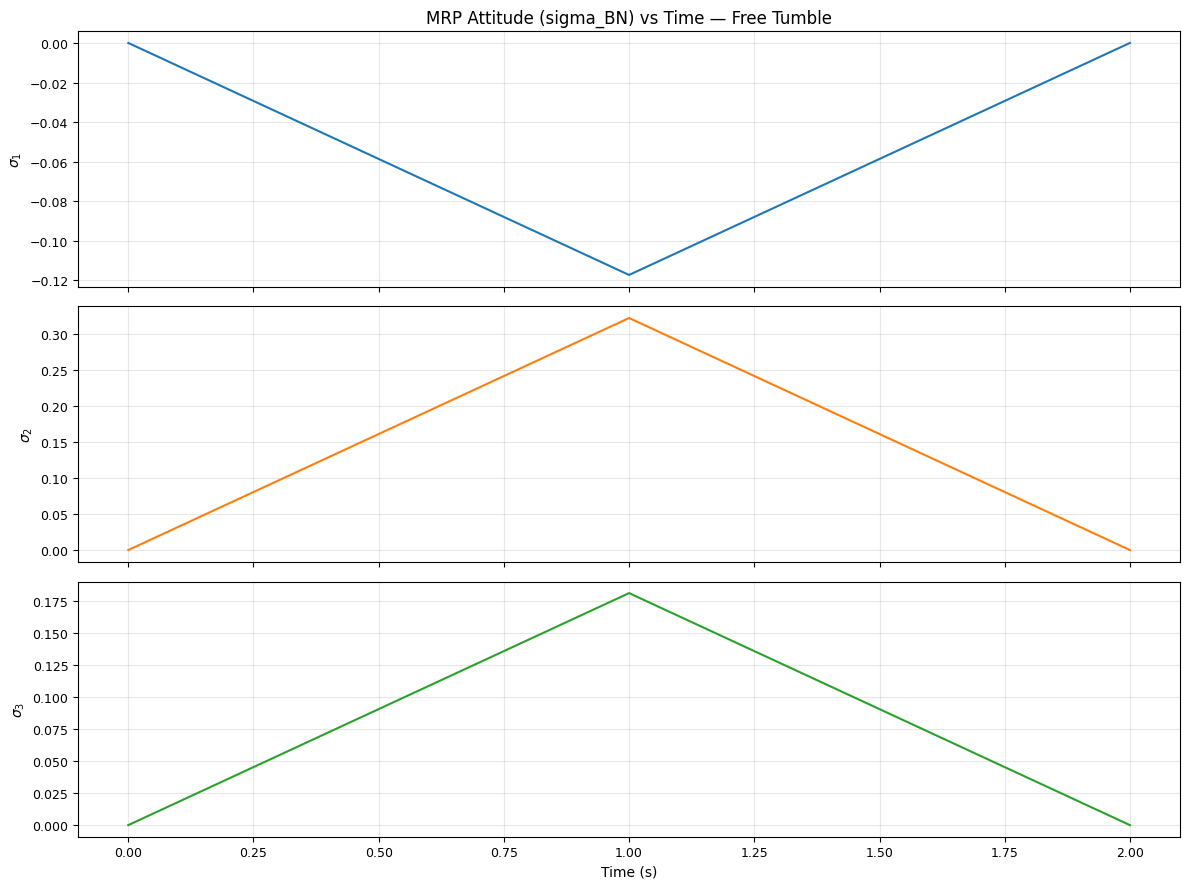

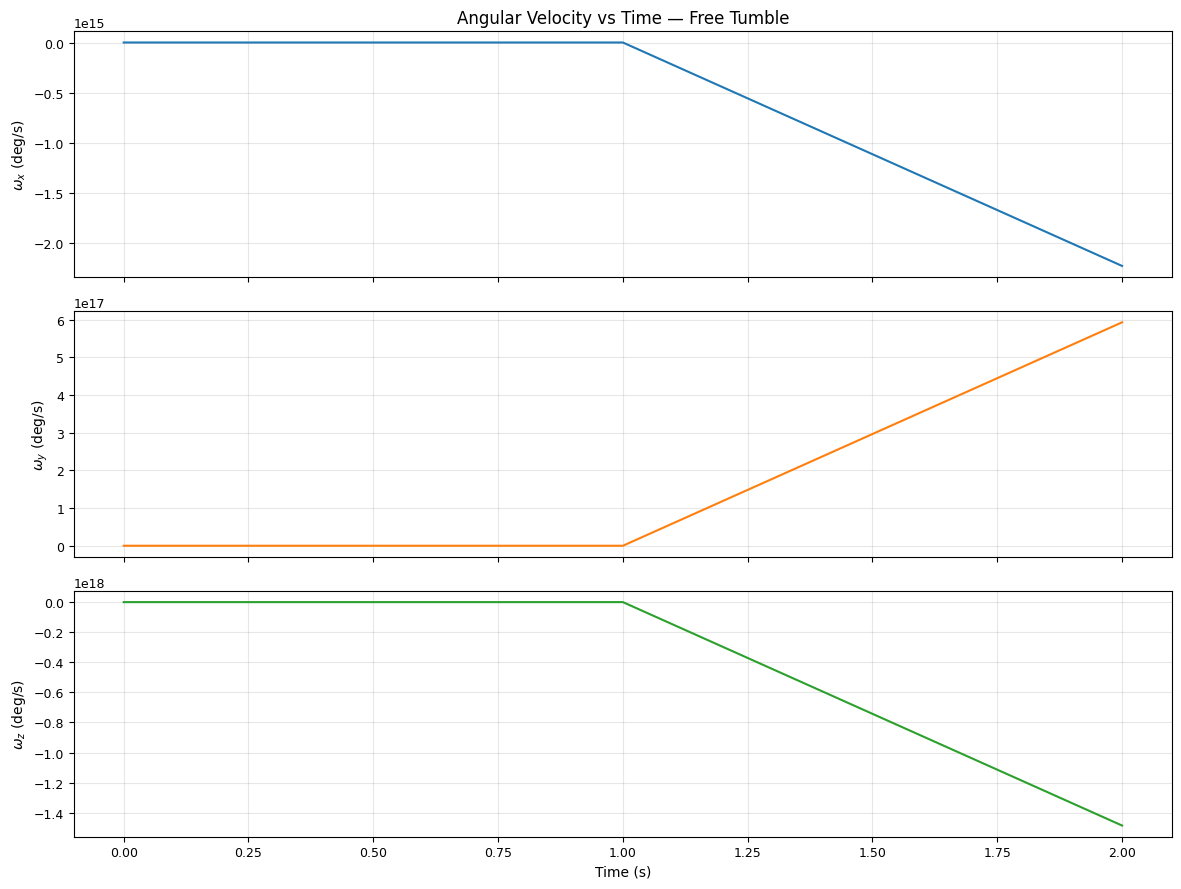

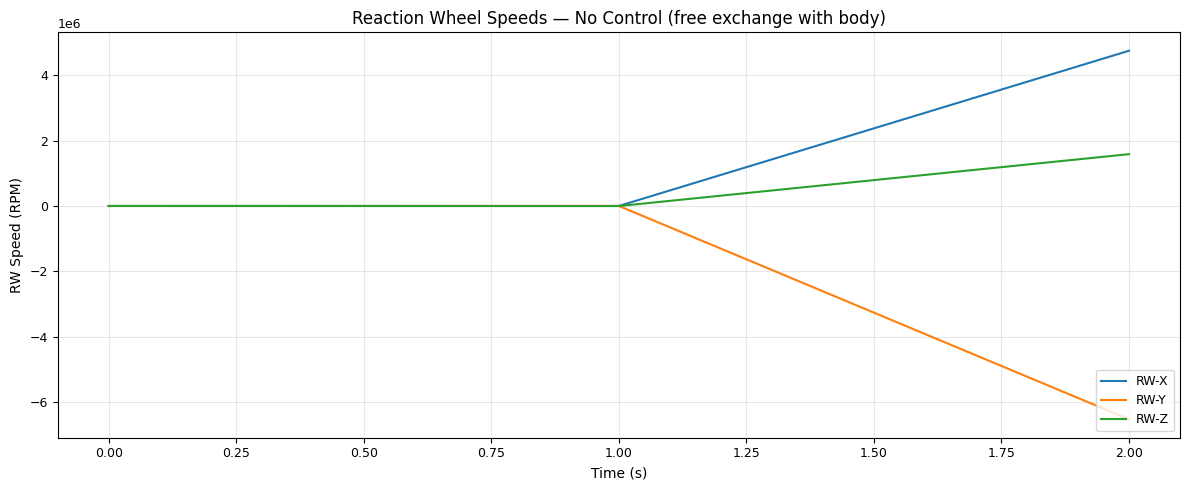

In [9]:
# ── Plot MRP attitude vs time ─────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
labels = [r'$\sigma_1$', r'$\sigma_2$', r'$\sigma_3$']
colors = ['tab:blue', 'tab:orange', 'tab:green']

for i in range(3):
    axes[i].plot(t, sigma[:, i], color=colors[i])
    axes[i].set_ylabel(labels[i])
    axes[i].grid(True, alpha=0.3)

axes[0].set_title('MRP Attitude (sigma_BN) vs Time — Free Tumble')
axes[2].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig('plots/03_mrp_attitude.png', dpi=100, bbox_inches='tight')
plt.show()

# ── Plot angular velocity vs time ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
axis_labels = [r'$\omega_x$ (rad/s)', r'$\omega_y$ (rad/s)', r'$\omega_z$ (rad/s)']

for i in range(3):
    axes[i].plot(t, omega[:, i] * macros.R2D, color=colors[i])
    axes[i].set_ylabel(axis_labels[i].replace('rad/s', 'deg/s'))
    axes[i].grid(True, alpha=0.3)

axes[0].set_title('Angular Velocity vs Time — Free Tumble')
axes[2].set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig('plots/03_angular_velocity.png', dpi=100, bbox_inches='tight')
plt.show()

# ── Plot RW speeds ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
rw_labels = ['RW-X', 'RW-Y', 'RW-Z']
for i in range(3):
    ax.plot(t, rwOmega[:, i] / macros.rpm2radsec, label=rw_labels[i], color=colors[i])

ax.set_xlabel('Time (s)')
ax.set_ylabel('RW Speed (RPM)')
ax.set_title('Reaction Wheel Speeds — No Control (free exchange with body)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/03_rw_speeds.png', dpi=100, bbox_inches='tight')
plt.show()

---

## 7. Angular Momentum Conservation Check

With no external torques, the **total angular momentum** (body + RWs) must be conserved.

H_norm range: nan — nan kg*m^2/s
Max conservation error: nan %


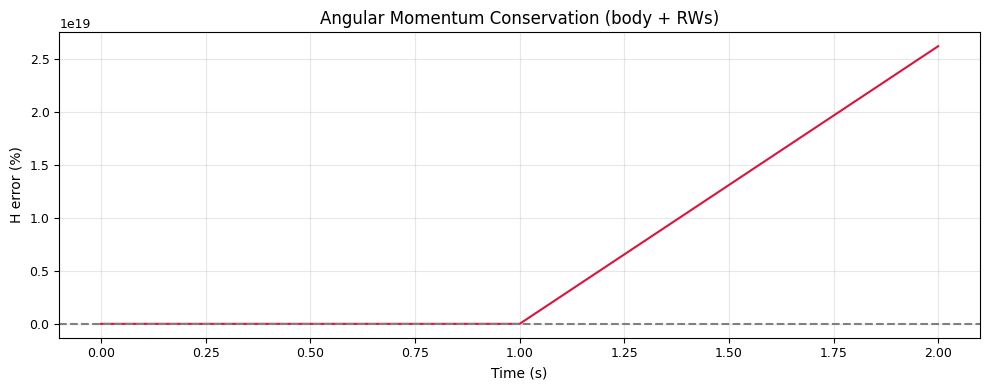

In [10]:
# Total angular momentum H = I_hub * omega_body + sum(I_rw_i * omega_rw_i * gsHat_i)
# (simplified — treating principal-axis hub)
I_rw = 0.12e-3   # typical Honeywell HR16 wheel inertia [kg*m^2]
gsSpin = np.array([[1,0,0],[0,1,0],[0,0,1]], dtype=float)  # spin axes in body frame

H = np.zeros((len(t), 3))
for k in range(len(t)):
    H_body = I3x3 @ omega[k]
    H_rw   = sum(I_rw * rwOmega[k, i] * gsSpin[i] for i in range(3))
    H[k]   = H_body + H_rw

H_norm = np.linalg.norm(H, axis=1)
H_err  = (H_norm - H_norm[0]) / H_norm[0] * 100

print(f"H_norm range: {H_norm.min():.6e} — {H_norm.max():.6e} kg*m^2/s")
print(f"Max conservation error: {abs(H_err).max():.4e} %")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t, H_err, color='crimson')
ax.axhline(0, color='gray', linestyle='--')
ax.set_xlabel('Time (s)')
ax.set_ylabel('H error (%)')
ax.set_title('Angular Momentum Conservation (body + RWs)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Summary

| Concept | Implementation |
|---|---|
| Hub inertia & mass | `scObject.hub.mHub`, `IHubPntBc_B` (pass flattened 1D array) |
| Initial attitude | `scObject.hub.sigma_BNInit` (MRP) |
| Initial angular rate | `scObject.hub.omega_BN_BInit` |
| Dynamic effector (gravity) | `simIncludeGravBody.gravBodyFactory()` → `.addBodiesTo(scObject)` |
| State effector (RW) | `simIncludeRW.rwFactory()` → `rwStateEffector` → `addToSpacecraft()` |
| Attitude output | `scObject.scStateOutMsg` → `.sigma_BN`, `.omega_BN_B` |
| RW speed output | `rwStateEffector.rwSpeedOutMsg` → `.wheelSpeeds` |

**Next: [04 - Attitude Dynamics & Kinematics](04_attitude_dynamics.ipynb)**